# HEST-FM — pathology foundation model + ridge head

The HEST benchmark (Jaume et al., *NeurIPS 2024 Spotlight*)
showed that the strongest recipe for predicting spatial
expression from H&E is also the simplest: take a pretrained
pathology foundation model (UNI / CONCH / Virchow2 /
GigaPath / CTransPath / …), extract per-tile features, fit
one ridge regression per gene on a paired Visium slide, and
predict on new tiles. With ≥1 paired reference slide this
beats most end-to-end deep architectures while training in
seconds.

`ov.space.histo.predict_expression(method='hest_fm')`
implements this recipe end-to-end on top of LazySlide /
WSIData.

**Why "with paired reference"?** A single Visium slide gives
you 3–5 k (tile, expression) training pairs, more than
enough to fit a stable linear head per gene. This is in
contrast to STPath / STFlow which are pretrained
cross-cohort and can run zero-shot on a brand-new H&E.

This notebook uses the **all-public CTransPath** backbone so
it runs without any HuggingFace gating. For higher accuracy
swap in `fm_backbone='uni2'`, `'conch_v1.5'`, `'virchow2'`,
or `'gigapath'` once you have access.

## Environment

In [1]:
import warnings
warnings.filterwarnings('ignore')

import omicverse as ov
import lazyslide as zs

ov.utils.ov_plot_set()
print('omicverse', ov.__version__, '| lazyslide', zs.__version__)

🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse 2.2.1rc1 | lazyslide 0.9.2


## How the WSI flows through LazySlide

`ov.space.histo` does **not** re-implement WSI handling —
it wraps [LazySlide](https://github.com/RendeiroLab/LazySlide)
(the scverse-aligned WSI toolkit) and lifts its `WSIData`
container into the omicverse namespace. Concretely:

| omicverse call | LazySlide / wsidata under the hood |
|---|---|
| `ov.space.histo.open_wsi(path)` | `wsidata.open_wsi(path)` — returns a `WSIData` (a `SpatialData` subclass) wrapping the slide reader (openslide / tiffslide / bioformats) and a thumbnail |
| `ov.space.histo.tile(wsi, …)` | `zs.pp.find_tissues` + `zs.pp.tile_tissues` — writes tissue contours to `wsi.shapes['tissues']` and a tile grid to `wsi.shapes['tiles']` |
| `ov.space.histo.embed(wsi, model=…)` | `zs.tl.feature_extraction` — runs the chosen pathology FM on every tile and stores features as `wsi.tables['{model}_tiles']` (an AnnData with one row per tile) |
| `ov.space.histo.predict_expression(wsi, method=…)` | omicverse-specific: writes another AnnData table `wsi.tables['{method}_tiles']` with predicted gene expression |

The `WSIData` API surface stays available — drop down to
`zs.pp.*` / `zs.tl.*` / `zs.pl.*` whenever you need finer
control than the convenience wrappers expose.

## Inputs HEST-FM expects

Two objects, both in the *same pixel coordinate frame*:

- **`reference` — paired Visium AnnData**
  - `reference.X` (n_spots × n_genes) — raw spot counts
  - `reference.obsm['spatial']` (n_spots × 2) — spot pixel
    centroids in the H&E frame
  - `reference.uns['spatial'][lib]['scalefactors']['spot_diameter_fullres']`
    — the spot diameter in full-resolution pixels; HEST-FM
    uses it as the side length of the reference patches it
    cuts out under each spot
- **`wsi` — `wsidata.WSIData`** wrapping the H&E used in the
  reference, plus optionally any *query* H&E you want to
  predict on. In this tutorial both reference and query are
  the same slide, but you can also tile and embed a
  *different* slide as the query as long as its tile
  features come from the same `fm_backbone`.

Both objects are returned together by `load_breast()`; the
next markdown cell shows how to assemble them for your own
data.

## Model weights & cache layout

HEST-FM uses **one pretrained foundation-model checkpoint**
(the patch encoder) and trains a tiny ridge head per gene
on the user's reference. Everything is auto-downloaded on
first use; nothing needs manual setup beyond the install.

| What | From | To | Size | Gated? |
|---|---|---|---|---|
| `ctranspath` patch encoder (default) | LazySlide model registry → HF `RendeiroLab/LazySlide-models-gpl` | `$HF_HOME/hub/` (default `~/.cache/huggingface/hub`) | ~100 MB | no |
| reference spot-patch features (per slide / backbone) | computed once | `$OV_HISTO_CACHE/ref_features/{backbone}_{slide_stem}_n{n_spots}.h5ad` | ~10–50 MB | — |
| query tile features (per slide / tile-grid / backbone) | computed once | `$OV_HISTO_CACHE/tile_features/{backbone}_{slide_stem}_{tile_key}_n{n_tiles}.h5ad` | ~10–50 MB | — |
| per-gene Ridge head | trained at predict time | in-memory, not persisted | — | — |

`$OV_HISTO_CACHE` defaults to `~/.cache/omicverse/histo`.
Override the location with `OV_HISTO_CACHE=/some/path`
(recommended on HPC: point it at a scratch filesystem).
Override the HuggingFace location with `HF_HOME=/some/path`
(default `~/.cache/huggingface`).

**Swapping to a more accurate gated backbone** — set
`fm_backbone='uni2'` (or `'conch_v1.5'`, `'virchow2'`,
`'gigapath'`, `'h-optimus-1'`) once you have HuggingFace
access. Request access on the model card, then
`huggingface-cli login` once on this machine. LazySlide
handles the gated download for you.

## Load the demo dataset

`ov.space.histo.load_breast()` downloads and caches the 10x Visium Breast Cancer Block A Section 1 sample under `$OV_HISTO_CACHE/he_zoo/visium_breast` (~1.7 GB on disk; one-time).

In [2]:
adata, wsi = ov.space.histo.load_breast()
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'histo'
    obsm: 'spatial'

WSI: /scratch/users/steorra/cache/omicverse_histo/he_zoo/visium_breast/V1_Breast_Cancer_Block_A_Section_1_image.tif
Reader: tiffslide
Dimensions: 24240×24240 (h×w), 1 Pyramid
Pixel physical size: 0.3098911012751 MPP
SpatialData object
└── Images
      └── 'wsi_thumbnail': DataArray[cyx] (3, 2000, 2000)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images)
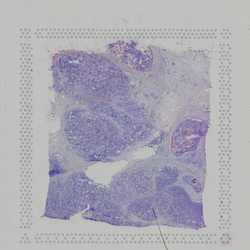

In [3]:
wsi

### Loading your own data

For a real Space Ranger output:

```python
adata, wsi = ov.space.histo.read_visium_with_image(
    visium_path='/path/to/spaceranger/outs',
    image_path='/path/to/full_resolution_HE.tif',
    count_file='filtered_feature_bc_matrix.h5',
)
```

The helper delegates to scverse-stack readers and `wsidata.open_wsi`
for you and derives `wsi.properties.mpp` from
`spot_diameter_fullres` so the downstream backends know the
physical scale. Predicting on a *different* slide than the
reference works the same way — just pass that slide's `wsi`
(after `tile()` + `embed()`) as the first argument while
keeping `reference=` pointed at the Visium AnnData you
already have.

## Tile and embed the WSI

- `tile(wsi, tile_px=224, mpp=0.5)` runs LazySlide's
  `find_tissues` + `tile_tissues`. `tile_px=224` matches
  every pathology FM's input size, and `mpp=0.5` (µm /
  pixel) is the standard "pathology zoom" level — each
  224-pixel patch covers ~112 µm of tissue, roughly twice a
  Visium spot's footprint.
- `embed(wsi, model='ctranspath', batch_size=16, num_workers=0)`
  extracts per-tile features and writes them as
  `wsi.tables['ctranspath_tiles']` (an AnnData with one row
  per tile and 768 feature columns). The on-disk cache key
  includes slide id, tile key, tile count, and backbone, so
  re-running this cell on the same WSI returns instantly.

In [4]:
ov.space.histo.tile(wsi, tile_px=224, mpp=0.5)
ov.space.histo.embed(wsi, model='ctranspath',
                     batch_size=16, num_workers=0)
print('tiles:', len(wsi.shapes['tiles']),
      '| feature table:', list(wsi.tables))

tiles: 1426 | feature table: ['ctranspath_tiles']


## Fit a Ridge head on the reference and predict on the query

`predict_expression(method='hest_fm', …)` does the following
under the hood:

1. cut out a 1-tile-per-spot grid on the reference WSI at
   `tile_px = spot_diameter_fullres`,
2. embed those reference patches with `fm_backbone` (cached
   to `$OV_HISTO_CACHE/ref_features/`),
3. PCA-project both reference and query embeddings to
   `n_components` dimensions,
4. fit one `sklearn.linear_model.Ridge` per requested gene on
   the reference, predict on the query tile features,
5. wrap predictions in an AnnData and store it as
   `wsi.tables['hest_fm_tiles']`.

### Key parameters

- `reference` — paired Visium AnnData (required for
  `hest_fm`).
- `genes=['EPCAM', …]` — gene panel to predict. Pass
  `None` to predict all of `reference.var_names`.
- `fm_backbone='ctranspath'` — which pathology FM to extract
  features with. List all options with
  `ov.space.histo.available_backbones()`.
- `n_components=128` — PCA dimensionality. Smaller =
  faster + more regularised; larger = retain more FM
  signal at the cost of overfitting risk on small
  references.
- `alpha=1.0` — Ridge regularisation strength. Increase if
  the head overfits (Pearson on held-out spots drops).
- `head='ridge'` — set to `'mlp'` for a 2-layer GELU MLP
  fitted with AdamW; usually a small gain on dense panels,
  not worth the extra compute on a 5-gene panel.

### Pre-staging the patch-encoder weights

HEST-FM downloads the chosen FM from the LazySlide registry
on first use. To run **air-gapped** (or to use a checkpoint
you've validated elsewhere) pass an explicit path:

```python
pred = ov.space.histo.predict_expression(
    wsi, method='hest_fm', reference=adata,
    fm_backbone='ctranspath',
    fm_weight_path='/path/to/ctranspath.pth',  # skips HF download
    hf_token=None,                              # not needed when path is given
    cache_dir='/path/to/scratch/omicverse_histo',
)
```

In [5]:
genes = ['EPCAM', 'ERBB2', 'CD68', 'ACTA2', 'VIM']
pred = ov.space.histo.predict_expression(
    wsi,
    method='hest_fm',
    reference=adata,
    genes=genes,
    fm_backbone='ctranspath',
    n_components=128,
    alpha=1.0,
)
pred

AnnData object with n_obs × n_vars = 1426 × 5
    obs: 'tile_id', 'library_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'histo'
    obsm: 'spatial'

## Reading the output

`pred` is an `AnnData` whose **rows are query tiles** (NOT
Visium spots) and whose **columns are the requested genes**:

- `pred.X` (n_tiles × n_genes) — log1p predicted expression,
  `float32`
- `pred.var_names` — the requested gene symbols
- `pred.obsm['spatial']` (n_tiles × 2) — tile pixel
  centroids, ready for any spatial plotter
- `pred.uns['histo']` — run metadata (`method`,
  `fm_backbone`, `n_components`, `alpha`, `head`)

In [6]:
print('shape       :', pred.shape)
print('var_names   :', list(pred.var_names))
print('coords range:', pred.obsm['spatial'].min(0), '→',
                       pred.obsm['spatial'].max(0))
print('metadata    :', pred.uns['histo'])

shape       : (1426, 5)
var_names   : ['EPCAM', 'ERBB2', 'CD68', 'ACTA2', 'VIM']
coords range: [4468.5 4355.5] → [22223.5 23521.5]
metadata    : {'method': 'hest_fm', 'fm_backbone': 'ctranspath', 'n_components': 128, 'alpha': 1.0, 'head': 'ridge'}


## Visualise predictions on the tissue

Tile-pixel centroids are in `obsm['spatial']`, so any spatial plotter (`ov.pl.embedding` / `ov.pl.spatial`, `zs.pl.tiles`) works directly. For high tile counts (3k+) `ov.pl.embedding` is the fastest path; `zs.pl.tiles(style='heatmap')` is useful for publication-quality renders that paint the WSI under the patches.

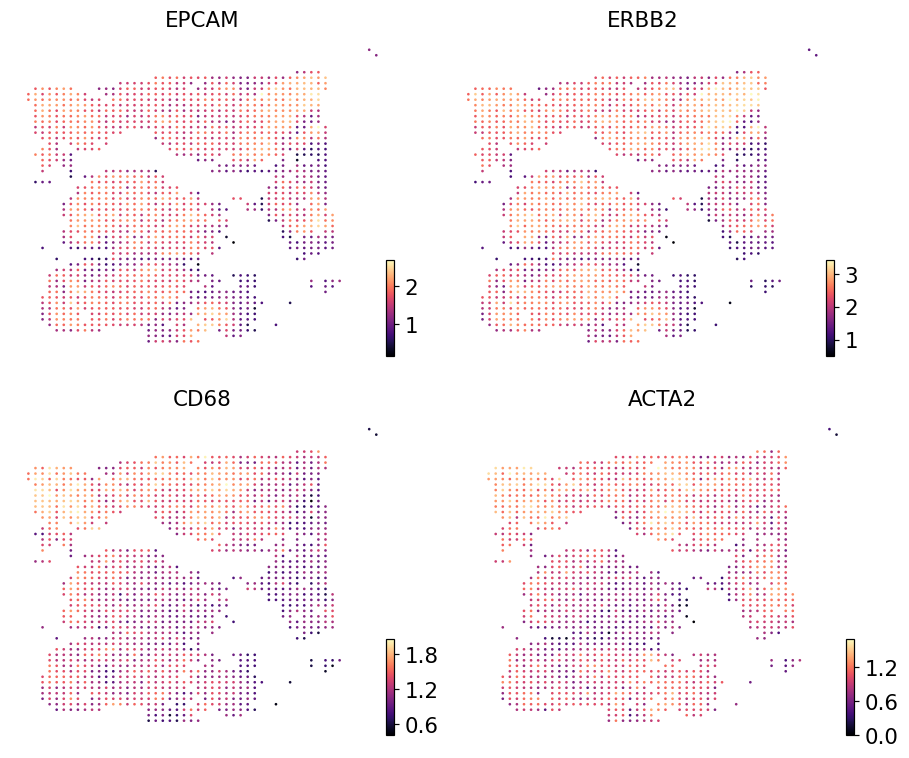

In [7]:
ov.pl.embedding(pred, basis='spatial',
                color=['EPCAM', 'ERBB2', 'CD68', 'ACTA2'],
                cmap='magma', s=12, ncols=2, frameon=False)

### Real Visium counts for the same genes

Render the same four genes from the paired Visium reference so they can be eyeballed against the predictions above. The reference is log1p-normalised (`ov.pp.normalize_total` + `ov.pp.log1p`) so the colour scale matches the predictor's output.


🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,798 cells × 36,601 genes
   ✓ Runtime: 0.06s


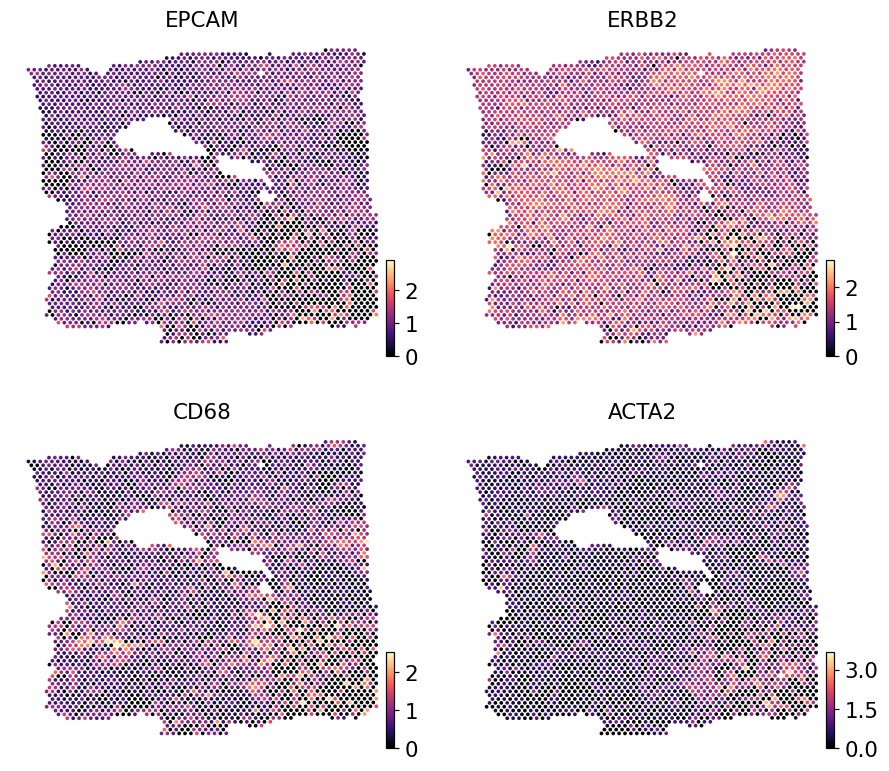

In [8]:
ref = adata.copy()
ov.pp.normalize_total(ref, target_sum=1e4)
ov.pp.log1p(ref)
ov.pl.embedding(ref, basis='spatial',
                color=['EPCAM', 'ERBB2', 'CD68', 'ACTA2'],
                cmap='magma', s=24, ncols=2, frameon=False)

### Per-gene scatter on Section 1 (training fit quality)

The ridge head was trained on Section 1's spots, so this scatter shows the **best-case fit** — how well the model can reproduce its own training data. Tile and spot grids don't coincide, so each Visium spot is matched to its nearest predicted tile before plotting. Pearson r is shown in the title; the dashed line is `predicted = true`.

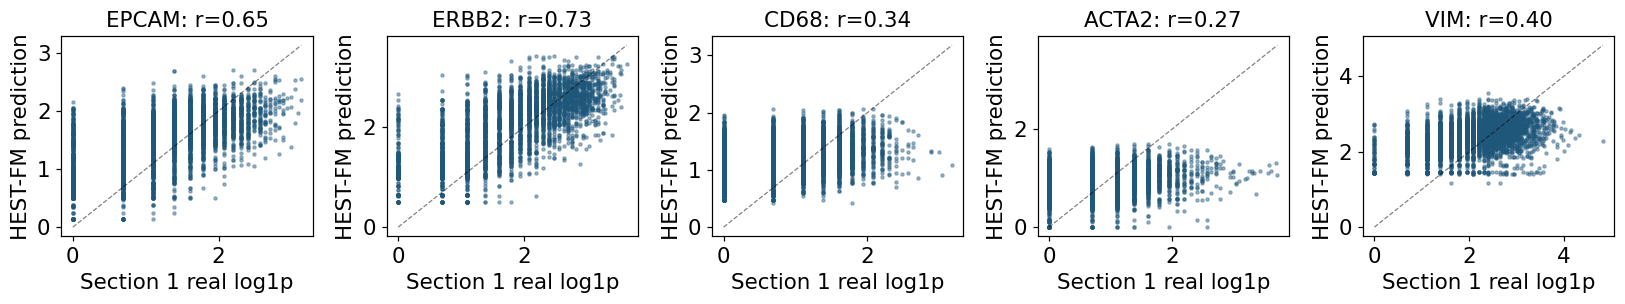

In [9]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr

spot_xy = adata.obsm['spatial']
tile_xy = pred.obsm['spatial']
nn = cKDTree(tile_xy).query(spot_xy, k=1)[1]

ref_X = adata[:, pred.var_names].X
ref_X = np.log1p(ref_X.toarray() if hasattr(ref_X, 'toarray') else ref_X)
pred_X = pred.X[nn]

fig, axes = plt.subplots(1, len(pred.var_names),
                         figsize=(3 * len(pred.var_names), 3))
for ax, g, i in zip(axes, pred.var_names, range(len(pred.var_names))):
    ax.scatter(ref_X[:, i], pred_X[:, i], s=4, alpha=0.4)
    r, _ = pearsonr(ref_X[:, i], pred_X[:, i])
    lo = float(min(ref_X[:, i].min(), pred_X[:, i].min()))
    hi = float(max(ref_X[:, i].max(), pred_X[:, i].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f'{g}: r={r:.2f}')
    ax.set_xlabel('Section 1 real log1p')
    ax.set_ylabel('HEST-FM prediction')
plt.tight_layout()

## Held-out evaluation on a fresh slide (Section 2)

The Pearson table above mixes "training data" (the H&E
patches the ridge head saw) with the comparison spots, so
it overestimates real-world quality. To get an honest
number, predict on **Section 2** — the adjacent physical
section of the same patient block, available from 10x as a
second Visium dataset. Same anatomy, same staining batch,
but every H&E pixel is genuinely new to the model.

`load_breast(section=2)` downloads it (~1.7 GB on first
use, then cached) and returns the same ``(adata, wsi)``
shape as Section 1.

In [10]:
adata_s2, wsi_s2 = ov.space.histo.load_breast(section=2)
ov.space.histo.tile(wsi_s2, tile_px=224, mpp=0.5)
ov.space.histo.embed(wsi_s2, model='ctranspath',
                     batch_size=16, num_workers=0)
adata_s2, wsi_s2

(AnnData object with n_obs × n_vars = 3987 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'histo'
    obsm: 'spatial', WSI: /scratch/users/steorra/cache/omicverse_histo/he_zoo/visium_breast_s2/V1_Breast_Cancer_Block_A_Section_2_image.tif
Reader: tiffslide
Dimensions: 24240×24240 (h×w), 1 Pyramid
Pixel physical size: 0.3099797227629586 MPP
SpatialData object
├── Images
│     └── 'wsi_thumbnail': DataArray[cyx] (3, 2000, 2000)
├── Shapes
│     ├── 'tiles': GeoDataFrame shape: (1857, 3) (2D shapes)
│     └── 'tissues': GeoDataFrame shape: (1, 2) (2D shapes)
└── Tables
      └── 'ctranspath_tiles': AnnData (1857, 768)
with coordinate systems:
    ▸ 'global', with elements:
        wsi_thumbnail (Images), tiles (Shapes), tissues (Shapes))

Predict on Section 2's tiles using the same call shape — only ``wsi=`` and the reference change.

In [11]:
pred_s2 = ov.space.histo.predict_expression(
    wsi_s2,                       # query: Section 2 H&E tiles
    method='hest_fm',
    reference=adata,              # train: Section 1 Visium spots
    genes=genes,                  # same 5-gene panel
    fm_backbone='ctranspath',
    n_components=128, alpha=1.0,
)
pred_s2

AnnData object with n_obs × n_vars = 1857 × 5
    obs: 'tile_id', 'library_id'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'histo'
    obsm: 'spatial'

### Spatial visualisation on Section 2 — prediction

Same `ov.pl.embedding` call as Section 1, just pointed at the held-out slide's predicted AnnData.

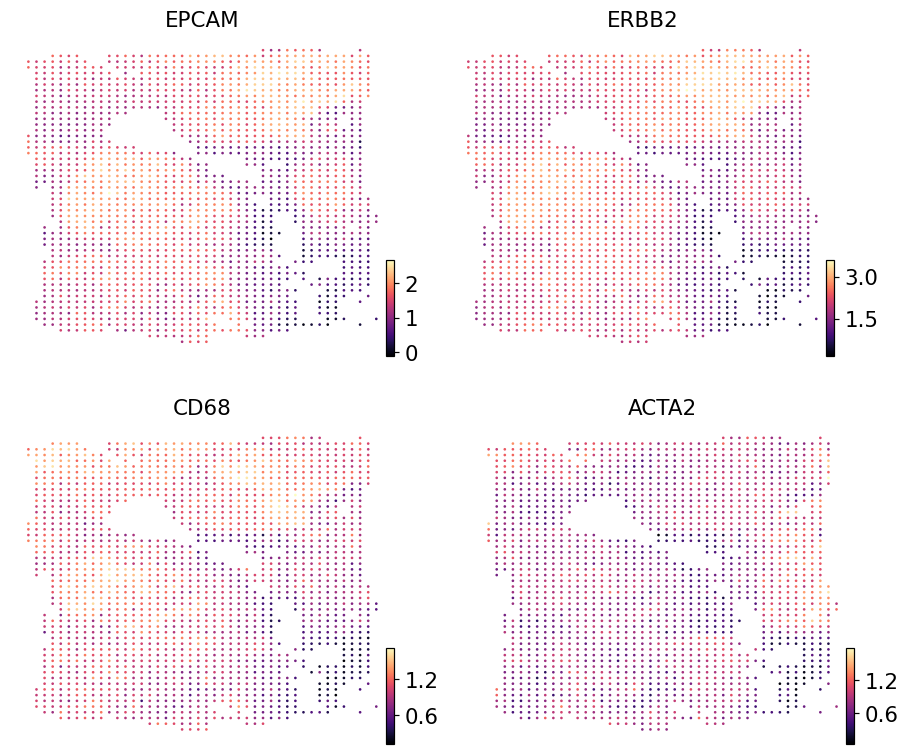

In [12]:
ov.pl.embedding(pred_s2, basis='spatial',
                color=['EPCAM', 'ERBB2', 'CD68', 'ACTA2'],
                cmap='magma', s=12, ncols=2, frameon=False)

### Spatial visualisation on Section 2 — real Visium counts

Section 2's real Visium expression for the same panel; compare visually with the predicted maps above. Log1p-normalised so the colour scale matches the predictor's output.


🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 3,987 cells × 36,601 genes
   ✓ Runtime: 0.06s


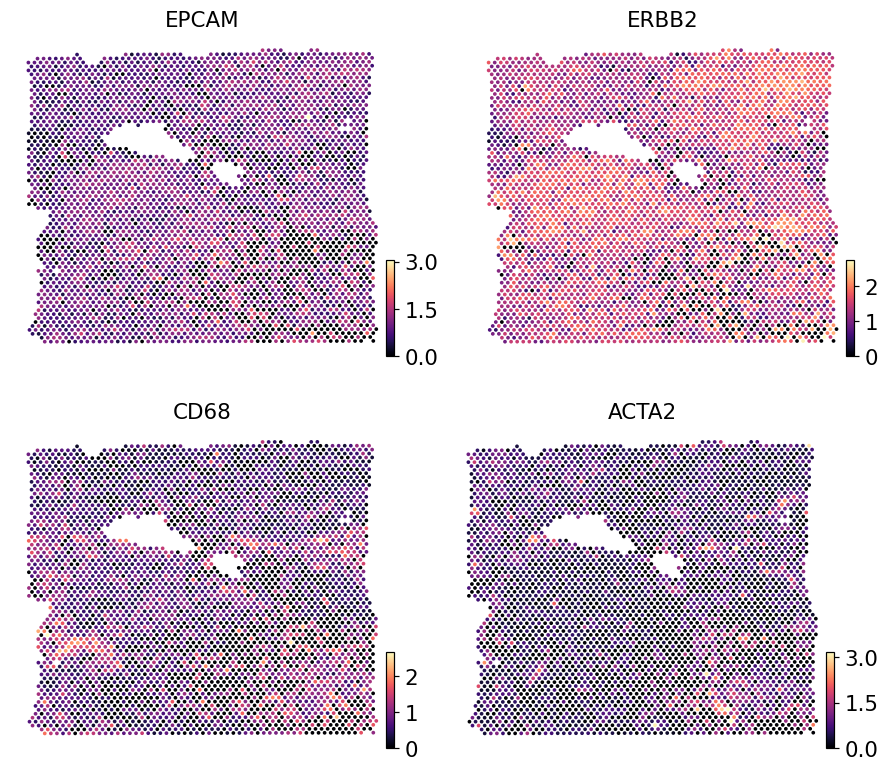

In [13]:
ref_s2 = adata_s2.copy()
ov.pp.normalize_total(ref_s2, target_sum=1e4)
ov.pp.log1p(ref_s2)
ov.pl.embedding(ref_s2, basis='spatial',
                color=['EPCAM', 'ERBB2', 'CD68', 'ACTA2'],
                cmap='magma', s=24, ncols=2, frameon=False)

### Per-gene scatter on Section 2 (truly held-out)

Match each Section 2 Visium spot to its nearest Section 2 predicted tile, scatter the real log1p expression against the prediction. Pearson r in the title.

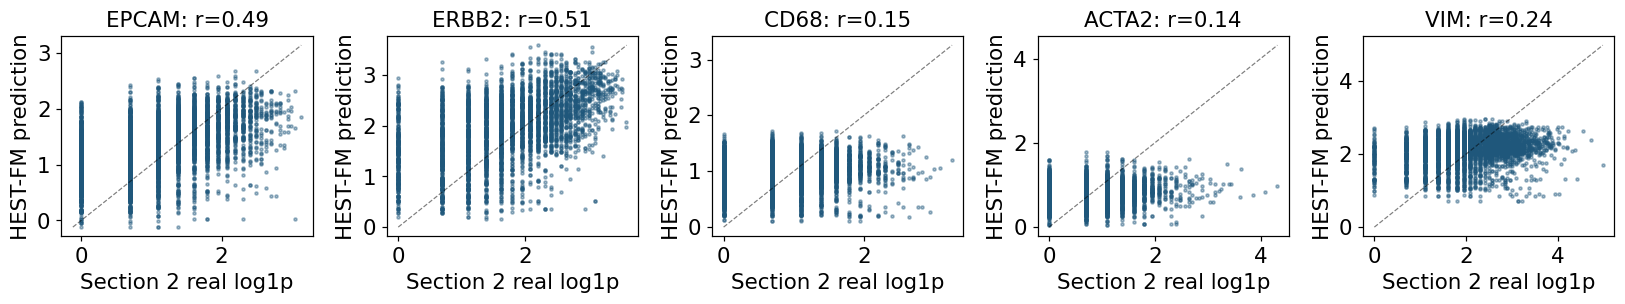

In [14]:
import numpy as np, matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr

spot_xy = adata_s2.obsm['spatial']
tile_xy = pred_s2.obsm['spatial']
nn = cKDTree(tile_xy).query(spot_xy, k=1)[1]

ref_X = adata_s2[:, pred_s2.var_names].X
ref_X = np.log1p(ref_X.toarray() if hasattr(ref_X, 'toarray') else ref_X)
pred_X = pred_s2.X[nn]

fig, axes = plt.subplots(1, len(pred_s2.var_names),
                         figsize=(3 * len(pred_s2.var_names), 3))
for ax, g, i in zip(axes, pred_s2.var_names, range(len(pred_s2.var_names))):
    ax.scatter(ref_X[:, i], pred_X[:, i], s=4, alpha=0.4)
    r, _ = pearsonr(ref_X[:, i], pred_X[:, i])
    lo = float(min(ref_X[:, i].min(), pred_X[:, i].min()))
    hi = float(max(ref_X[:, i].max(), pred_X[:, i].max()))
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f'{g}: r={r:.2f}')
    ax.set_xlabel('Section 2 real log1p')
    ax.set_ylabel('HEST-FM prediction')
plt.tight_layout()

**Reading the numbers** — per-gene Pearson r ≈ 0.3–0.7 is typical for the *all-public* CTransPath backbone on a 5-gene panel. Two things noticeably move it up:

- swap `fm_backbone='uni2'` / `'virchow2'` / `'gigapath'` (gated, see [model card](https://huggingface.co/MahmoodLab/UNI2-h)) — typically +5-15% mean r;
- bump the panel size (HEST-Bench fits 50 HVG ridges per slide, which stabilises the alpha pick).

The dashed diagonal is `predicted = true`; the more the cloud hugs it, the better.

## Where to go next

The predicted AnnData is interchangeable with a real Visium
table, so downstream `ov.space` analyses just work:

```python
ov.space.pySTAGATE(pred, n_domains=8, radius=20)   # spatial domains
pred = ov.space.svg(pred, mode='prost', n_svgs=200)  # spatially-variable genes
ov.pl.spatial(pred, color='STAGATE_domain')
```

Compare with the other HE-zoo backends on the same H&E:
[STPath](t_histo_stpath.ipynb),
[STFlow](t_histo_stflow.ipynb),
[iStar](t_histo_istar.ipynb).